# 04. Baseline 모델 구축 (Baseline Modeling)

## 프로젝트: 반도체 수율 예측 (Semiconductor Yield Prediction)

### 분석 목적

본 Notebook에서는 SECOM 반도체 제조 데이터에 대한
기본 분류 모델(Baseline Model)을 구축한다.

Baseline 모델의 목적은 높은 성능을 만드는 것이 아니라,
이후 클래스 불균형 처리, Feature Selection, XGBoost 및
Hyperparameter Tuning을 적용했을 때 성능이 얼마나 개선되었는지를
비교하기 위한 기준점을 확보하는 것이다.

본 단계에서는 다음 두 모델을 비교한다.

1. **Dummy Classifier**
   - 모든 샘플을 다수 클래스인 Pass로 예측하는 기준 모델

2. **Logistic Regression**
   - 클래스 불균형 보정을 적용하지 않은 기본 분류 모델

SECOM 데이터는 Fail 비율이 약 6.6%에 불과하므로,
Accuracy만으로 모델 성능을 판단하지 않고
Fail 클래스의 Recall, Precision, F1/F2-score 및 PR-AUC를 함께 평가한다.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

set_config(display="text")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 1. 데이터 준비

Baseline 모델에서도 이전 전처리 단계와 동일한 데이터 분할 기준을 사용한다.

재현성을 유지하기 위해 다음 설정을 동일하게 적용한다.

- Test Size: 20%
- `random_state=42`
- `stratify=y`

또한 Feature 제거 기준은 Test Data를 사용하지 않고
Training Data만을 이용하여 결정한다.

이를 통해 `03_preprocessing.ipynb`에서 설계한
Data Leakage 방지 원칙을 동일하게 유지한다.

In [2]:
DATA_PATH = Path("../data/processed/uci-secom.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (1567, 592)


In [3]:
feature_cols = [
    col for col in df.columns
    if col.startswith("feature_")
]

X = df[feature_cols].copy()

y = (
    df["Pass/Fail"]
    .replace({
        -1: 0,
        1: 1
    })
    .astype(int)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

X shape: (1567, 590)
y shape: (1567,)

Target distribution:
Pass/Fail
0    1463
1     104
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print(f"\nTrain Fail Rate: {y_train.mean() * 100:.2f}%")
print(f"Test Fail Rate : {y_test.mean() * 100:.2f}%")

X_train: (1253, 590)
X_test : (314, 590)

Train Fail Rate: 6.62%
Test Fail Rate : 6.69%


### Training Data 기반 Feature 품질 검사

Baseline 모델에서도 전처리 기준은 Training Data에서만 계산한다.

다음 조건 중 하나 이상에 해당하는 센서 변수를 제거 대상으로 선정한다.

- Training Data에서 결측률이 40% 이상인 변수
- 모든 값이 결측인 변수
- 하나의 값만 가지는 비정보 변수

Test Data에서는 별도의 제거 기준을 계산하지 않고,
Training Data에서 결정된 동일한 Feature 목록을 적용한다.

In [6]:
train_missing_ratio = (
    X_train
    .isna()
    .mean()
    .mul(100)
)

high_missing_features = (
    train_missing_ratio[
        train_missing_ratio >= 40
    ]
    .index
    .tolist()
)

all_missing_features_train = [
    col for col in X_train.columns
    if X_train[col].isna().all()
]

single_value_features_train = [
    col for col in X_train.columns
    if X_train[col].nunique(dropna=True) == 1
]

features_to_remove = sorted(
    set(
        high_missing_features
        + all_missing_features_train
        + single_value_features_train
    )
)

print("High-missing features :", len(high_missing_features))
print("All-missing features  :", len(all_missing_features_train))
print("Single-value features :", len(single_value_features_train))
print("Total features removed:", len(features_to_remove))

High-missing features : 32
All-missing features  : 0
Single-value features : 116
Total features removed: 148


In [7]:
X_train_filtered = X_train.drop(
    columns=features_to_remove
).copy()

X_test_filtered = X_test.drop(
    columns=features_to_remove
).copy()

print("X_train_filtered:", X_train_filtered.shape)
print("X_test_filtered :", X_test_filtered.shape)

assert X_train_filtered.columns.equals(
    X_test_filtered.columns
)

print("\nFeature filtering validation passed.")

X_train_filtered: (1253, 442)
X_test_filtered : (314, 442)

Feature filtering validation passed.


## 2. Dummy Classifier Baseline

첫 번째 Baseline으로 Dummy Classifier를 사용한다.

`strategy="most_frequent"`를 적용하면 모델은 입력 센서값과 관계없이
Training Data에서 가장 많이 존재하는 클래스만을 예측한다.

SECOM 데이터에서는 Pass가 약 93%를 차지하므로
모든 샘플을 Pass라고 예측해도 높은 Accuracy가 나타날 수 있다.

이를 통해 클래스 불균형이 심한 데이터에서
Accuracy만으로 모델 성능을 판단하는 것이 왜 위험한지 확인한다.

In [8]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train_filtered,
    y_train
)

dummy_pred = dummy_model.predict(
    X_test_filtered
)

dummy_prob = dummy_model.predict_proba(
    X_test_filtered
)[:, 1]

In [9]:
print("Dummy predicted classes:")
print(
    pd.Series(dummy_pred)
    .value_counts()
    .sort_index()
)

Dummy predicted classes:
0    314
Name: count, dtype: int64


In [10]:
dummy_accuracy = accuracy_score(
    y_test,
    dummy_pred
)

dummy_precision = precision_score(
    y_test,
    dummy_pred,
    zero_division=0
)

dummy_recall = recall_score(
    y_test,
    dummy_pred,
    zero_division=0
)

dummy_f1 = f1_score(
    y_test,
    dummy_pred,
    zero_division=0
)

dummy_f2 = fbeta_score(
    y_test,
    dummy_pred,
    beta=2,
    zero_division=0
)

dummy_pr_auc = average_precision_score(
    y_test,
    dummy_prob
)

dummy_roc_auc = roc_auc_score(
    y_test,
    dummy_prob
)

print(f"Accuracy  : {dummy_accuracy:.4f}")
print(f"Precision : {dummy_precision:.4f}")
print(f"Recall    : {dummy_recall:.4f}")
print(f"F1-score  : {dummy_f1:.4f}")
print(f"F2-score  : {dummy_f2:.4f}")
print(f"PR-AUC    : {dummy_pr_auc:.4f}")
print(f"ROC-AUC   : {dummy_roc_auc:.4f}")

Accuracy  : 0.9331
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
F2-score  : 0.0000
PR-AUC    : 0.0669
ROC-AUC   : 0.5000


In [11]:
dummy_cm = confusion_matrix(
    y_test,
    dummy_pred
)

print(dummy_cm)

[[293   0]
 [ 21   0]]


In [12]:
print(
    classification_report(
        y_test,
        dummy_pred,
        target_names=[
            "Pass",
            "Fail"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Pass       0.93      1.00      0.97       293
        Fail       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



### Dummy Classifier 결과 해석

Dummy Classifier는 모든 샘플을 다수 클래스인 Pass로 예측한다.

따라서 전체 데이터의 대부분을 차지하는 Pass 샘플 덕분에
높은 Accuracy가 나타날 수 있다.

그러나 Fail 클래스의 Recall이 0이라면,
실제 불량 샘플을 단 하나도 검출하지 못했다는 의미이다.

이는 심각한 클래스 불균형을 가진 SECOM 데이터에서
Accuracy만으로 모델 성능을 평가하는 것이 적절하지 않음을 보여준다.

반도체 품질 관점에서는 실제 Fail을 Pass로 판단하는
False Negative가 발생하면 불량 제품이 정상으로 분류될 수 있으므로,
Fail Recall과 False Negative 수를 중요한 평가 기준으로 고려해야 한다.

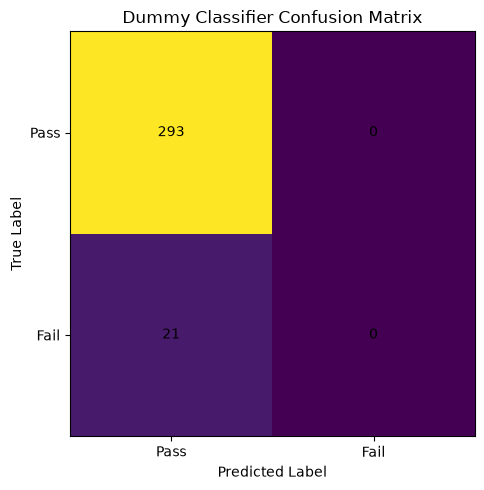

Saved to: ..\results\figures\dummy_confusion_matrix.png


In [13]:
DUMMY_CM_PATH = Path(
    "../results/figures/dummy_confusion_matrix.png"
)

plt.figure(figsize=(6, 5))

plt.imshow(dummy_cm)

plt.title("Dummy Classifier Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Pass", "Fail"]
)

plt.yticks(
    [0, 1],
    ["Pass", "Fail"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            dummy_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    DUMMY_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", DUMMY_CM_PATH)

## 3. Logistic Regression Baseline

두 번째 Baseline으로 Logistic Regression을 사용한다.

Dummy Classifier와 달리 Logistic Regression은
센서 변수의 값을 이용하여 Pass/Fail을 구분한다.

그러나 본 단계에서는 클래스 불균형 문제에 대한 별도의 보정을 적용하지 않는다.

따라서 아직 다음 방법들은 사용하지 않는다.

- SMOTE
- Class Weight 조정
- Feature Selection
- Hyperparameter Tuning

본 결과는 이후 클래스 불균형 처리 및 고도화 모델과 비교하기 위한
기본 머신러닝 성능(Baseline Performance)으로 사용한다.

### Logistic Regression Pipeline

Logistic Regression 모델은 결측값을 직접 사용할 수 없으므로,
전처리와 모델 학습을 하나의 Pipeline으로 구성한다.

Pipeline의 처리 순서는 다음과 같다.

1. Median Imputation
2. Standard Scaling
3. Logistic Regression

Median Imputation과 Scaling 기준은 Training Data에서 학습되고,
동일한 변환이 Test Data에 적용된다.

본 Baseline에서는 클래스 불균형 자체의 영향을 확인하기 위해
`class_weight="balanced"`는 사용하지 않는다.

In [17]:
logistic_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])

print(logistic_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=5000, random_state=42))])


In [19]:
logistic_pipeline.fit(
    X_train_filtered,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [20]:
model_is_fitted = hasattr(
    logistic_pipeline.named_steps["model"],
    "coef_"
)

print("Model fitted:", model_is_fitted)

Model fitted: True


In [21]:
logistic_pred = logistic_pipeline.predict(
    X_test_filtered
)

logistic_prob = logistic_pipeline.predict_proba(
    X_test_filtered
)[:, 1]

In [22]:
print("Prediction completed.")
print("Predictions:", len(logistic_pred))

Prediction completed.
Predictions: 314


In [23]:
print("Logistic predicted classes:")

print(
    pd.Series(logistic_pred)
    .value_counts()
    .sort_index()
)

Logistic predicted classes:
0    290
1     24
Name: count, dtype: int64


In [24]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_f2 = fbeta_score(
    y_test,
    logistic_pred,
    beta=2,
    zero_division=0
)

logistic_pr_auc = average_precision_score(
    y_test,
    logistic_prob
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_prob
)

print(f"Accuracy  : {logistic_accuracy:.4f}")
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"F1-score  : {logistic_f1:.4f}")
print(f"F2-score  : {logistic_f2:.4f}")
print(f"PR-AUC    : {logistic_pr_auc:.4f}")
print(f"ROC-AUC   : {logistic_roc_auc:.4f}")

Accuracy  : 0.8758
Precision : 0.1250
Recall    : 0.1429
F1-score  : 0.1333
F2-score  : 0.1389
PR-AUC    : 0.1190
ROC-AUC   : 0.6205


In [25]:
print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=[
            "Pass",
            "Fail"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Pass       0.94      0.93      0.93       293
        Fail       0.12      0.14      0.13        21

    accuracy                           0.88       314
   macro avg       0.53      0.54      0.53       314
weighted avg       0.88      0.88      0.88       314



In [26]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_pred
)

print(logistic_cm)

[[272  21]
 [ 18   3]]


TN = 285
→ 실제 Pass를 Pass로 예측

FP = 8
→ 실제 Pass인데 Fail이라고 예측

FN = 15
→ 실제 Fail인데 Pass라고 예측 ⚠️

TP = 6
→ 실제 Fail을 Fail로 예측

False Negative

를 얼마나 줄이느냐가 이후 SMOTE 적용의 핵심이 된다.

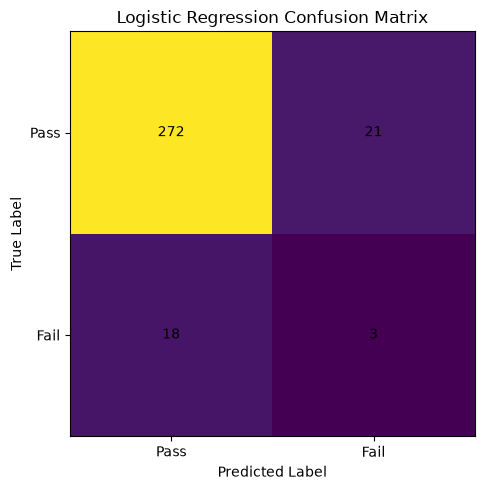

Saved to: ..\results\figures\logistic_confusion_matrix.png


In [27]:
LOGISTIC_CM_PATH = Path(
    "../results/figures/logistic_confusion_matrix.png"
)

plt.figure(figsize=(6, 5))

plt.imshow(logistic_cm)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Pass", "Fail"]
)

plt.yticks(
    [0, 1],
    ["Pass", "Fail"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            logistic_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    LOGISTIC_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", LOGISTIC_CM_PATH)

## 4. Baseline 모델 성능 비교

Dummy Classifier와 Logistic Regression의 성능을 동일한 평가 지표를 이용하여 비교한다.

특히 높은 Accuracy 자체보다 실제 Fail 클래스에 대한 검출 성능을 중심으로 평가한다.

주요 평가 지표는 다음과 같다.

- Accuracy
- Precision
- Recall
- F1-score
- F2-score
- PR-AUC
- ROC-AUC

F2-score는 Precision보다 Recall에 더 높은 가중치를 부여하기 때문에,
실제 Fail을 놓치지 않는 것이 중요한 본 프로젝트에서 보조 평가 지표로 활용한다.

In [28]:
baseline_results = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression"
    ],

    "Accuracy": [
        dummy_accuracy,
        logistic_accuracy
    ],

    "Precision": [
        dummy_precision,
        logistic_precision
    ],

    "Recall": [
        dummy_recall,
        logistic_recall
    ],

    "F1": [
        dummy_f1,
        logistic_f1
    ],

    "F2": [
        dummy_f2,
        logistic_f2
    ],

    "PR-AUC": [
        dummy_pr_auc,
        logistic_pr_auc
    ],

    "ROC-AUC": [
        dummy_roc_auc,
        logistic_roc_auc
    ]
})

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC
0,Dummy Classifier,0.9331,0.000,0.0000,0.0000,0.0000,0.0669,0.5000
1,Logistic Regression,0.8758,0.125,0.1429,0.1333,0.1389,0.1190,0.6205


In [29]:
baseline_results = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression"
    ],

    "Accuracy": [
        dummy_accuracy,
        logistic_accuracy
    ],

    "Precision": [
        dummy_precision,
        logistic_precision
    ],

    "Recall": [
        dummy_recall,
        logistic_recall
    ],

    "F1": [
        dummy_f1,
        logistic_f1
    ],

    "F2": [
        dummy_f2,
        logistic_f2
    ],

    "PR-AUC": [
        dummy_pr_auc,
        logistic_pr_auc
    ],

    "ROC-AUC": [
        dummy_roc_auc,
        logistic_roc_auc
    ]
})

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC
0,Dummy Classifier,0.9331,0.000,0.0000,0.0000,0.0000,0.0669,0.5000
1,Logistic Regression,0.8758,0.125,0.1429,0.1333,0.1389,0.1190,0.6205


In [30]:
RESULT_PATH = Path(
    "../results/metrics/baseline_model_results.csv"
)

baseline_results.to_csv(
    RESULT_PATH,
    index=False
)

print("Saved to:", RESULT_PATH)
print("File exists:", RESULT_PATH.exists())

Saved to: ..\results\metrics\baseline_model_results.csv
File exists: True


In [31]:
RESULT_PATH = Path(
    "../results/metrics/baseline_model_results.csv"
)

baseline_results.to_csv(
    RESULT_PATH,
    index=False
)

print("Saved to:", RESULT_PATH)
print("File exists:", RESULT_PATH.exists())

Saved to: ..\results\metrics\baseline_model_results.csv
File exists: True


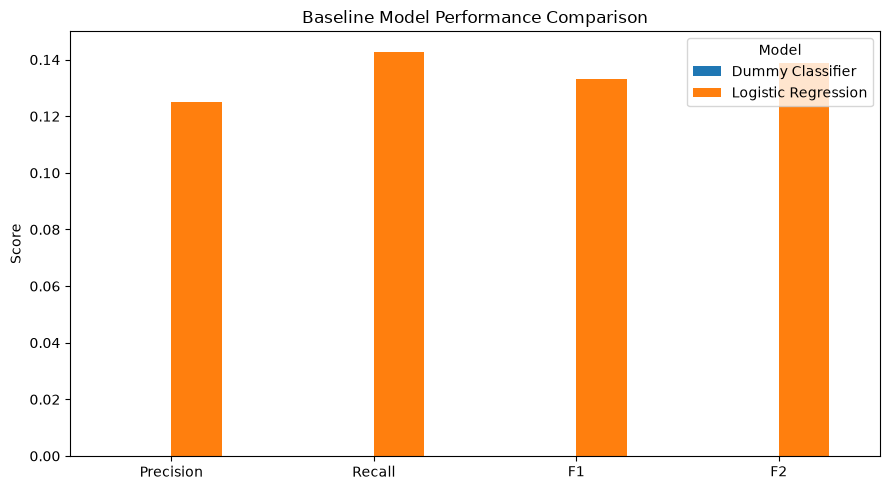

Saved to: ..\results\figures\baseline_model_comparison.png


In [32]:
comparison_metrics = [
    "Precision",
    "Recall",
    "F1",
    "F2"
]

baseline_results.set_index("Model")[
    comparison_metrics
].T.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Score")
plt.title("Baseline Model Performance Comparison")

plt.xticks(rotation=0)

plt.tight_layout()

BASELINE_FIGURE_PATH = Path(
    "../results/figures/baseline_model_comparison.png"
)

plt.savefig(
    BASELINE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved to:",
    BASELINE_FIGURE_PATH
)

## 5. Baseline 모델링 종합 결과

본 단계에서는 Dummy Classifier와 Logistic Regression을 이용하여
SECOM 반도체 불량 예측의 기준 성능(Baseline Performance)을 구축하였다.

### 1. Dummy Classifier

Dummy Classifier는 모든 Test 샘플을 다수 클래스인 Pass로 예측하였다.

그 결과 Accuracy는 약 **93.31%**로 매우 높게 나타났지만,
Fail 클래스에 대한 Precision, Recall, F1-score 및 F2-score는
모두 0으로 나타났다.

Test Data에 존재하는 실제 Fail 샘플 21개를
단 하나도 검출하지 못했으며,

- True Positive: 0개
- False Negative: 21개

로 확인되었다.

이는 SECOM과 같이 클래스 불균형이 심한 데이터에서
Accuracy만으로 모델 성능을 평가할 경우
실제 불량 검출 능력을 심각하게 과대평가할 수 있음을 보여준다.


### 2. Logistic Regression

센서 변수의 정보를 이용하는 Logistic Regression은
Accuracy 약 **87.58%**를 기록하였다.

Dummy Classifier보다 Accuracy는 낮아졌지만,
Fail 클래스에 대해서는 다음과 같은 성능을 보였다.

- Precision: **12.50%**
- Recall: **14.29%**
- F1-score: **13.33%**
- F2-score: **13.89%**
- PR-AUC: **0.1190**
- ROC-AUC: **0.6205**

Confusion Matrix를 분석한 결과,

- True Negative: 272개
- False Positive: 21개
- False Negative: 18개
- True Positive: 3개

로 나타났다.

즉 실제 Fail 샘플 21개 중 3개를 검출하였으나,
18개의 Fail 샘플을 Pass로 잘못 판단하였다.

Dummy Classifier와 비교하면 Fail 검출 능력이 발생하기 시작했으며,
PR-AUC 또한 0.0669에서 0.1190으로 개선되었다.

그러나 Fail Recall이 약 14.29%에 불과하여
실제 불량의 대부분을 여전히 놓치고 있다.


### 3. Baseline 모델 비교의 의미

Dummy Classifier의 Accuracy는 Logistic Regression보다 높았지만,
실제 Fail 검출 성능은 전혀 존재하지 않았다.

따라서 본 프로젝트에서는 단순 Accuracy 향상보다
다음 항목을 중심으로 모델 개선 여부를 평가한다.

- Fail Recall 향상
- False Negative 감소
- Precision과 Recall의 균형
- F1/F2-score 향상
- PR-AUC 향상

특히 반도체 품질 관점에서는 실제 Fail을 Pass로 판단하는
False Negative를 줄이는 것이 중요한 목표가 된다.


## 다음 단계

Baseline Logistic Regression에서는 클래스 불균형에 대한
별도의 보정을 적용하지 않았다.

다음 단계에서는 SMOTE(Synthetic Minority Over-sampling Technique)를
Training 과정에 적용하여 소수 클래스인 Fail 샘플의 학습 정보를 보강한다.

SMOTE 적용 전후의 성능을 비교하여 다음 질문을 확인한다.

1. Fail Recall이 얼마나 향상되는가?
2. False Negative가 얼마나 감소하는가?
3. Recall 향상 과정에서 Precision은 얼마나 감소하는가?
4. F1/F2-score와 PR-AUC는 실제로 개선되는가?

이를 통해 클래스 불균형 처리가
SECOM 불량 예측 성능에 미치는 영향을 평가한다.